### **Package**

In [1]:
import subprocess
import sys
import os

print(sys.version)

try:
    import pymoo
    print("pymoo is already installed.")
except ImportError:
    print("pymoo is not installed. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pymoo"])
print("pymoo installed.")

try:
    from autogluon.tabular import TabularPredictor
    print("AutoGluon is already installed.")
except ImportError:
    print("AutoGluon is not installed. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "autogluon.tabular"])
    print("AutoGluon installed.")

try:
    import modact
    print("modact is already installed.")
except ImportError:
    print("modact is not installed. Installing from GitHub...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/epfl-lamd/modact.git"])
    print("modact has been successfully installed.")

import warnings
warnings.filterwarnings("ignore", message=".*load_learner.*pickle.*")

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pymoo is not installed. Installing...
pymoo installed.
AutoGluon is not installed. Installing...
AutoGluon installed.
modact is not installed. Installing from GitHub...
modact has been successfully installed.


In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from pymoo.operators.sampling.lhs import LHS
from pymoo.problems import get_problem
from pymoo.core.problem import Problem
from pymoo.util.ref_dirs import get_reference_directions
import plotly.graph_objects as go


# Optimization algorithm
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.termination import get_termination
from pymoo.core.survival import Survival
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.operators.survival.rank_and_crowding.metrics import get_crowding_function
from pymoo.util.randomized_argsort import randomized_argsort
from pymoo.problems.multi import MODAct
from pymoo.problems.multi.omnitest import OmniTest


# Surrogate model
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from autogluon.tabular import TabularPredictor


# Metrics
from pymoo.indicators.hv import HV
from pymoo.indicators.igd_plus import IGDPlus
from sklearn.metrics import mean_squared_error

### **Class and Function**

In [ ]:
from pymoo.core.callback import Callback
from IPython.display import clear_output

class EvaluatePreRealCallback(Callback):
    def __init__(self, true_problem, plot_every=1, use_opt=True, dynamic_show=False,
                 prefix="", obj_min=None, obj_max=None, hv_indicator=None):
        super().__init__()
        self.true_problem = true_problem
        self.plot_every = plot_every
        self.use_opt = use_opt
        self.dynamic_show = dynamic_show
        self.prefix = prefix
        self.max_f_so_far = None
        self.obj_min = None if obj_min is None else np.asarray(obj_min, dtype=float)
        self.obj_max = None if obj_max is None else np.asarray(obj_max, dtype=float)
        self.hv_indicator = hv_indicator
        self.records = []

    def notify(self, algorithm):
        gen = algorithm.n_gen

        if gen % self.plot_every != 0:
            return

        pop = algorithm.opt if self.use_opt else algorithm.pop
        X = pop.get("X")
        pre = pop.get("F")
        real = self.true_problem.evaluate(X, return_values_of=["F"])

        hv_sur = None
        hv_real = None
        if self.hv_indicator is not None and self.obj_min is not None and self.obj_max is not None:
            pre_norm = (pre - self.obj_min) / (self.obj_max - self.obj_min)
            real_norm = (real - self.obj_min) / (self.obj_max - self.obj_min)
            hv_sur = float(self.hv_indicator.do(pre_norm))
            hv_real = float(self.hv_indicator.do(real_norm))

        if self.dynamic_show:
            clear_output(wait=True)

        max_pre = np.max(pre, axis=0)
        max_real = np.max(real, axis=0)
        max_f = np.maximum(max_pre, max_real)

        if self.max_f_so_far is None:
            self.max_f_so_far = max_f.copy()
        else:
            self.max_f_so_far = np.maximum(self.max_f_so_far, max_f)

        print(f"[{self.prefix}] Generation {gen}")
        print(f"Max f1: {self.max_f_so_far[0]:.2f}| {self.obj_max[0] * 1.1 :.2f}")
        print(f"Max f2: {self.max_f_so_far[1]:.2f}| {self.obj_max[1] * 1.1 :.2f}")

        if hv_sur is not None and hv_real is not None:
            print(f"HV sur : {hv_sur:.4f}")
            print(f"HV real: {hv_real:.4f}")

        result = evaluate_pre_real(
            pre,
            real,
            title=f"{self.prefix} | Gen {gen}",
            show_plot=True
        )

        self.records.append({
            "gen": gen,
            "X": X.copy(),
            "pre": pre.copy(),
            "real": real.copy(),
            "hv_sur": hv_sur,
            "hv_real": hv_real,
            **result
        })

###### Plot and Metrics

In [ ]:
# Plot: 2 Objs and pareto front
def plot_obj_2d(F, xlim=(0, 1), ylim=(0, 1),):
    n_obj = F.shape[1]
    if n_obj == 2:
        nds = NonDominatedSorting()
        front_idx = nds.do(F, only_non_dominated_front=True)

        pareto_F = F[front_idx]
        non_pareto_F = np.delete(F, front_idx, axis=0)

        fig = go.Figure(
            data=go.Scatter(
                x=F[:, 0],
                y=F[:, 1],
                mode='markers',
                name='Objective Values',
                marker=dict(size=6, color='#87CEEB', opacity=0.7)
            )
        )
        fig.add_trace(go.Scatter(
            x=pareto_F[:, 0],
            y=pareto_F[:, 1],
            mode='markers',
            name='Pareto Front',
            marker=dict(size=7, color='#FF7F0E', opacity=0.9, symbol='diamond')
    ))
        fig.update_layout(
            xaxis_title='f1',
            yaxis_title='f2',
            width=600,
            height=600,
            xaxis=dict(range=list(xlim)),
            yaxis=dict(range=list(ylim))
        )
    fig.show()


def mean_std(arr):
    return np.mean(arr), np.std(arr)

In [ ]:
def evaluate_pre_real(pre, real, title=None, figsize=(7, 6), point_size=20, show_plot=True):
    pre = np.asarray(pre, dtype=float)
    real = np.asarray(real, dtype=float)

    if pre.ndim != 2 or real.ndim != 2:
        raise ValueError("pre and real must be 2D arrays.")
    if pre.shape[1] != 2 or real.shape[1] != 2:
        raise ValueError("pre and real must have shape (n, 2).")
    if pre.shape[0] != real.shape[0]:
        raise ValueError("pre and real must have the same number of rows.")

    # row-wise Euclidean distance
    distances = np.sqrt(np.sum((pre - real) ** 2, axis=1))

    max_idx = np.argmax(distances)
    min_idx = np.argmin(distances)

    result = {
        "distances": distances,
        "max_distance": distances[max_idx],
        "max_obj_point": pre[max_idx],
        "max_f_real_point": real[max_idx],
        "min_distance": distances[min_idx],
        "min_obj_point": pre[min_idx],
        "min_f_real_point": real[min_idx],
        "mean_distance": np.mean(distances)
    }

    if show_plot:
        fig, ax = plt.subplots(figsize=figsize)

        for i in range(pre.shape[0]):
            ax.annotate(
                '',
                xy=(real[i, 0], real[i, 1]),
                xytext=(pre[i, 0], pre[i, 1]),
                arrowprops=dict(
                    arrowstyle='->',
                    color='green',
                    lw=1.0,
                    alpha=0.8,
                    shrinkA=0,
                    shrinkB=0
                )
            )

        ax.scatter(
            pre[:, 0], pre[:, 1],
            color='#87CEEB',
            s=point_size,
            alpha=0.8,
            label='pre'
        )

        ax.scatter(
            real[:, 0], real[:, 1],
            color='#FF7F0E',
            s=point_size,
            alpha=0.8,
            label='real'
        )

        ax.set_xlabel('F1')
        ax.set_ylabel('F2')
        if title is not None:
            ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()

    print(f"Max:  {result['max_distance']:.2f}, sur={result['max_obj_point']}, real={result['max_f_real_point']}")
    print(f"Min:  {result['min_distance']:.2f}, sur={result['min_obj_point']}, real={result['min_f_real_point']}")
    print(f"Mean: {result['mean_distance']:.2f}")
    print("-" * 50)

    return result

###### Class: Surrogate model

In [ ]:
# Model: Autogluon_QR
def autogluon_QR(X_train, y_train, X_test):
    df_y = pd.DataFrame(X_train, columns=[f'x{i}' for i in range(X_train.shape[1])])
    df_y['target'] = y_train
    model = TabularPredictor(
        label='target',
        problem_type='quantile',
        quantile_levels=[0.5, 0.8, 0.9, 0.95],
        ).fit(train_data=df_y,
              verbosity=0,
              ag_args_fit={'random_state': 42})

    df_test = pd.DataFrame(X_test, columns=[f'x{i}' for i in range(X_test.shape[1])])
    pred_y = model.predict(df_test)
    pred_y.columns = [f'y_q{q}' for q in pred_y.columns]

    pred_y_q50 = pred_y['y_q0.5'].values
    pred_y_q80 = pred_y['y_q0.8'].values
    pred_y_q90 = pred_y['y_q0.9'].values
    pred_y_q95 = pred_y['y_q0.95'].values

    return pred_y_q50, pred_y_q80, pred_y_q90, pred_y_q95, model


###### Define Problem

In [ ]:
# Problem
class Benchmark_Problem(Problem):
    def __init__(self, model_f1, model_f2, n_var, n_obj, xl, xu, problem_name, use_surrogate):

        if 'dtlz' in problem_name:
          self.problem = get_problem(problem_name, n_var=n_var, n_obj=n_obj)
        elif 'omnitest' in problem_name:
          self.problem = OmniTest(n_var=n_var)
        else:
          self.problem = get_problem(problem_name)

        n_constr = self.problem.n_constr if self.problem.has_constraints() else 0

        super().__init__(n_var=n_var, n_obj=n_obj, xl=xl, xu=xu,
                         n_constr=n_constr, model=None,
                         evaluation_model=None)

        self.model_f1 = model_f1
        self.model_f2 = model_f2
        self.use_surrogate = use_surrogate

    def _evaluate(self, X, out, *args, **kwargs):

        self.use_surrogate == 'QR_uncertainty'
        df_test = pd.DataFrame(X, columns=[f'x{i}' for i in range(X.shape[1])])

        pred_y1 = self.model_f1.predict(df_test)
        pred_y1.columns = [f'y_q{q}' for q in pred_y1.columns]
        y1_q50  = pred_y1['y_q0.5'].values.reshape(-1, 1)
        y1_q80 = pred_y1['y_q0.8'].values.reshape(-1, 1)
        y1_q90 = pred_y1['y_q0.9'].values.reshape(-1, 1)
        y1_q95 = pred_y1['y_q0.95'].values.reshape(-1, 1)

        pred_y2 = self.model_f2.predict(df_test)
        pred_y2.columns = [f'y_q{q}' for q in pred_y2.columns]
        y2_q50  = pred_y2['y_q0.5'].values.reshape(-1, 1)
        y2_q80 = pred_y2['y_q0.8'].values.reshape(-1, 1)
        y2_q90 = pred_y2['y_q0.9'].values.reshape(-1, 1)
        y2_q95 = pred_y2['y_q0.95'].values.reshape(-1, 1)

        out["F"] = np.hstack([y1_q50, y2_q50])
        out["F_q80"] = np.hstack([y1_q80, y2_q80])
        out["F_q90"] = np.hstack([y1_q90, y2_q90])
        out["F_q95"] = np.hstack([y1_q95, y2_q95])

        if self.problem.has_constraints():
          out["G"] = self.problem.evaluate(X, return_values_of=["G"])


###### Class: Survival

In [ ]:
class Survival_standard(Survival):

    def __init__(self, nds=None, crowding_func="cd"):
        crowding_func_ = get_crowding_function(crowding_func)
        super().__init__(filter_infeasible=True)
        self.nds = nds if nds is not None else NonDominatedSorting()
        self.crowding_func = crowding_func_


    def _do(self,
            problem,
            pop,
            *args,
            random_state=None,
            n_survive=None,
            **kwargs):

        F = pop.get("F").astype(float, copy=False)

        survivors = []

        fronts = self.nds.do(F, n_stop_if_ranked=n_survive)

        for k, front in enumerate(fronts):

            I = np.arange(len(front))

            if len(survivors) + len(I) > n_survive:
                n_remove = len(survivors) + len(front) - n_survive
                crowding_of_front = \
                    self.crowding_func.do(
                        F[front, :],
                        n_remove=n_remove
                    )

                I = randomized_argsort(crowding_of_front, order='descending', method='numpy', random_state=random_state)
                I = I[:-n_remove]

            else:
                crowding_of_front = \
                    self.crowding_func.do(
                        F[front, :],
                        n_remove=0
                    )

            for j, i in enumerate(front):
                pop[i].set("rank", k)
                pop[i].set("crowding", crowding_of_front[j])
            survivors.extend(front[I])

        return pop[survivors]


###### Class: Survival_dual_ranking

In [ ]:
class Survival_dual_ranking(Survival):

    def __init__(self, nds=None, crowding_func="cd", alpha=1):
        crowding_func_ = get_crowding_function(crowding_func)
        super().__init__(filter_infeasible=True)
        self.nds = nds if nds is not None else NonDominatedSorting()
        self.crowding_func = crowding_func_
        self.alpha = alpha


    def _do(self,problem,pop,*args,random_state=None,n_survive=None,**kwargs):
        F = pop.get("F").astype(float, copy=False)
        F_q80 = pop.get("F_q80").astype(float, copy=False)
        F_q90 = pop.get("F_q90").astype(float, copy=False)
        F_q95 = pop.get("F_q95").astype(float, copy=False)

        #============= F_fix =====================
        if self.alpha == 0.8:
          F_hybrid = np.concatenate([F, F_q80], axis=1)
        elif self.alpha == 0.9:
          F_hybrid = np.concatenate([F, F_q90], axis=1)
        elif self.alpha == 0.95:
          F_hybrid = np.concatenate([F, F_q95], axis=1)
        #===========================================

        # ====== NonDominatedSorting ============
        fronts_hybrid = NonDominatedSorting().do(F_hybrid)
        #==========================================

        survivors = []
        for k, front in enumerate(fronts_hybrid):

            I = np.arange(len(front))

            if len(survivors) + len(I) > n_survive:
                n_remove = len(survivors) + len(front) - n_survive
                crowding_of_front = \
                    self.crowding_func.do(
                        F[front, :],
                        n_remove=n_remove
                    )

                I = randomized_argsort(crowding_of_front, order='descending', method='numpy', random_state=random_state)
                I = I[:-n_remove]

            else:
                crowding_of_front = \
                    self.crowding_func.do(
                        F[front, :],
                        n_remove=0
                    )

            for j, i in enumerate(front):
                pop[i].set("rank", k)
                pop[i].set("crowding", crowding_of_front[j])
            survivors.extend(front[I])

        return pop[survivors]


### **Main**

###### 1. Initial settings



In [ ]:
# Initial settings
# Problem: dtlz1-7, omnitest, bnh, truss2d, welded_beam
problem_name = 'dtlz1'

if 'dtlz' in problem_name:
  n_var = 10
  n_obj = 2
  problem = get_problem(problem_name, n_var=n_var, n_obj=n_obj)

elif 'omnitest' in problem_name:
  n_var = 2
  n_obj = 2
  problem = OmniTest(n_var=n_var)

else:
  problem = get_problem(problem_name)
  n_var = problem.n_var
  n_obj = problem.n_obj

print(f"Problem name: {problem_name}")
print(f"Cons: {problem.n_constr}")
print(f"Var: {n_var}")
print(f"Obj: {n_obj}")

# n_gen, pop_size
n_gen = 100
pop_size = 100
np.set_printoptions(precision=4, suppress=True)

# Data
# LHS sampling with seed 42
np.random.seed(42)
sample_size = 11*n_var-1
sampling = LHS()

X_train = sampling(problem, sample_size, seed=42).get("X")
y_train = problem.evaluate(X_train, return_values_of=["F"])
y_train_f1 = y_train[:, 0]
y_train_f2 = y_train[:, 1]
print('\nSampling X_train shape: ', X_train.shape)

X_val = sampling(problem, 100, seed=42).get("X")
y_val = problem.evaluate(X_val, return_values_of=["F"])
print('y_val shape: ', y_val.shape)

X_test = sampling(problem, 100, seed=1).get("X")
y_test = problem.evaluate(X_test, return_values_of=["F"])
print('y_test shape: ', y_test.shape)


# Metrics: HV
if problem_name == 'dtlz1':
  obj_min = np.array([0,0])
  obj_max = np.array([700,700])

if problem_name == 'dtlz2':
  obj_min = np.array([0,0])
  obj_max = np.array([2.78,2.93])

if problem_name == 'dtlz3':
  obj_min = np.array([0,0])
  obj_max = np.array([1605.54,1670.48])

if problem_name == 'dtlz4':
  obj_min = np.array([0,0])
  obj_max = np.array([2.83,2.78])

if problem_name == 'dtlz5':
  obj_min = np.array([0,0])
  obj_max = np.array([2.61,2.70])

if problem_name == 'dtlz6':
  obj_min = np.array([0,0])
  obj_max = np.array([9.78,9.78])

if problem_name == 'dtlz7':
  obj_min = np.array([0,0])
  obj_max = np.array([1.10,33.43])

if problem_name == 'omnitest':
  obj_min = np.array([-2,-2])
  obj_max = np.array([2.40,2.40])

if problem_name == 'bnh':
  obj_min = np.array([0,5])
  obj_max = np.array([140,50])

if problem_name == 'truss2d':
  obj_min = np.array([0,0])
  obj_max = np.array([0.1,1e5])

if problem_name == 'welded_beam':
  obj_min = np.array([0,0])
  obj_max = np.array([160,0.20])


ref_point = np.array([1.1,1.1])
hv = HV(ref_point=ref_point)
print('\nMin-Max normalization -> Min: ', obj_min)
print('Min-Max normalization -> Max: ', obj_max)
print('HV Reference points: ', ref_point)

# Metrics: IGD+
n_points = 200
if problem_name == 'dtlz5':
    X_opt = np.full((n_points, n_var), 0.5)
    X_opt[:, 0] = np.linspace(0, 1, n_points)
    pf = problem.evaluate(X_opt)

elif problem_name == 'dtlz6':
    X_opt = np.zeros((n_points, n_var))
    X_opt[:, 0] = np.linspace(0, 1, n_points)
    pf = problem.evaluate(X_opt)

elif problem_name == 'dtlz7':
    X_opt = np.zeros((n_points, n_var))
    X_opt[:, :n_obj-1] = np.linspace(0, 1, n_points).reshape(-1, 1)
    pf = problem.evaluate(X_opt)
else:
    pf = problem.pareto_front()
igd_plus = IGDPlus(pf)

Problem name: dtlz1
Cons: 0
Var: 10
Obj: 2

Sampling X_train shape:  (109, 10)
y_val shape:  (100, 2)
y_test shape:  (100, 2)

Min-Max normalization -> Min:  [0 0]
Min-Max normalization -> Max:  [700 700]
HV Reference points:  [1.1 1.1]


###### 2. Autogluon_QR surrogate model training

In [ ]:
# Autogluon-Tabular with QR
y1_q50, y1_q80, y1_q90, y1_q95, model_QR_f1 = autogluon_QR(X_train, y_train_f1, X_test)
y2_q50, y2_q80, y2_q90, y2_q95, model_QR_f2 = autogluon_QR(X_train, y_train_f2, X_test)
print('Autogluon-Tabular model finished.\n')

y_q50= np.stack([y1_q50, y2_q50], axis=1)
y_q80= np.stack([y1_q80, y2_q80], axis=1)
y_q90= np.stack([y1_q90, y2_q90], axis=1)
y_q95= np.stack([y1_q95, y2_q95], axis=1)

# Metrics
print(f"Autogluon-QR MSE: {mean_squared_error(y_test, y_q50):.2e}")

print('y_q50\n', y_q50[0:3])
print('y_q80\n', y_q80[0:3])
print('y_q90\n', y_q90[0:3])
print('y_q95\n', y_q95[0:3])

No path specified. Models will be saved in: "AutogluonModels/ag-20260402_150932"
		`import catboost` failed. A quick tip is to install via `pip install autogluon.tabular[catboost]==1.5.0`.
No path specified. Models will be saved in: "AutogluonModels/ag-20260402_151004"
		`import catboost` failed. A quick tip is to install via `pip install autogluon.tabular[catboost]==1.5.0`.


Autogluon-Tabular model finished.

Autogluon-QR MSE: 5.01e+03
y_q50
 [[275.1737 145.1692]
 [151.581  344.4452]
 [ 73.6955 397.1551]]
y_q80
 [[347.4115 181.2868]
 [199.1544 412.3208]
 [105.6145 451.083 ]]
y_q90
 [[415.5602 202.4653]
 [234.3518 448.3592]
 [119.2189 509.7042]]
y_q95
 [[468.7725 231.5666]
 [278.1912 470.1035]
 [169.909  522.9857]]


In [ ]:
###### CICP
"""
Interval    Coverage
±1.282σ      80.00%
±1.645σ      90.00%
±1.960σ      95.00%
"""
def coverage(y_test, y_q50, y_upper):
    err = np.abs(y_test - y_q50)
    inside = y_test <= y_upper
    per_dim = inside.mean(axis=0)
    overall = inside.mean()
    return per_dim, overall
print('Coverage')
for level, q_upper in [(0.90, y_q90)]:
    per_dim, overall = coverage(y_test, y_q50, q_upper)
    print(f"{int(level*100)}% interval: per_dim={per_dim*100}%, overall={overall*100:.1f}%")

Coverage
90% interval: per_dim=[94. 91.]%, overall=92.5%


###### 3. Optimization using QR

In [ ]:
# Algorithm
algorithm = NSGA2(
    pop_size=100,
    crossover = SBX(prob=1.0, eta=20),
    mutation = PM(prob=1/n_var, eta=20),
    survival=Survival_standard(),     ### change
    eliminate_duplicates=True)

mse_list, igd_list, hv_surrogate_list, hv_real_list,  = [], [], [], []

for seed in range(1, 2):
    benchmark_problem = Benchmark_Problem(
        model_f1=model_QR_f1,   ### change
        model_f2=model_QR_f2,   ### change
        n_var=n_var,
        n_obj=n_obj,
        xl=problem.xl,
        xu=problem.xu,
        problem_name=problem_name,
        use_surrogate='QR_uncertainty')   ### change

    # Optimization
    start_time = time.time()

    callback_standard = EvaluatePreRealCallback(
        true_problem=problem,
        plot_every=1,
        use_opt=True,
        dynamic_show=False,
        prefix="NSGA2-standard",
        obj_min=obj_min,
        obj_max=obj_max,
        hv_indicator=hv
    )

    res = minimize(
        benchmark_problem,
        algorithm,
        termination=get_termination("n_gen", n_gen),
        seed=seed,
        save_history=True,
        verbose=False,
        callback=callback_standard
    )


    end_time = time.time()

    solution = res.history[-1].opt.get("X")
    obj = res.history[-1].opt.get("F")
    f_real = problem.evaluate(solution, return_values_of=["F"])

    # MSE
    mse = mean_squared_error(f_real, obj)
    mse_list.append(mse)
    # IGD+
    igd_plus_real = float(igd_plus(f_real))
    igd_list.append(igd_plus_real)
    # HV
    f_real_normalization = (f_real - obj_min) / (obj_max - obj_min)
    obj_normalization = (obj - obj_min) / (obj_max - obj_min)
    hv_real = float(hv.do(f_real_normalization))
    hv_surrogate = float(hv.do(obj_normalization))
    hv_real_list.append(hv_real)
    hv_surrogate_list.append(hv_surrogate)

    max_obj = np.max(obj, axis=0)
    max_obj_real = np.max(f_real, axis=0)
    print(f"Seed {seed} | Time: {end_time - start_time:.2f}s | "
          f"MSE: {mse:.2e} | "
          f"igd+: {igd_plus_real:.2e} | "
          f"Sur HV: {hv_surrogate:.2f} | "
          f"Real HV: {hv_real:.2f} | "
          f"Max f_real: {max_obj_real}")

plot_obj_2d(obj,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))
plot_obj_2d(f_real,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# mean_mse, std_mse = mean_std(mse_list)
# mean_igd, std_igd = mean_std(igd_list)
# mean_hv_real, std_hv_real = mean_std(hv_real_list)
# mean_hv_surrogate, std_hv_surrogate = mean_std(hv_surrogate_list)

# print('Problem name: ', problem_name)
# print("\n=== QR ===")

# print(f"MSE: Mean = {mean_mse:.2e}, Std = {std_mse:.2e}")
# print(f"IGD+: Mean = {mean_igd:.2e}, Std = {std_igd:.2e}")
# print(f"Sur HV: Mean = {mean_hv_surrogate:.2f}, Std = {std_hv_surrogate:.2f}")
# print(f"Real HV: Mean = {mean_hv_real:.2f}, Std = {std_hv_real:.2f}")

###### 3. Optimization using QR + dual-ranking (q=0.90)

In [ ]:
# Algorithm
algorithm = NSGA2(
    pop_size=100,
    crossover = SBX(prob=1.0, eta=20),
    mutation = PM(prob=1/n_var, eta=20),
    survival=Survival_dual_ranking(alpha=0.9),     ### change
    eliminate_duplicates=True)

mse_list, igd_list, hv_surrogate_list, hv_real_list,  = [], [], [], []

for seed in range(1, 2):
    benchmark_problem = Benchmark_Problem(
        model_f1=model_QR_f1,   ### change
        model_f2=model_QR_f2,   ### change
        n_var=n_var,
        n_obj=n_obj,
        xl=problem.xl,
        xu=problem.xu,
        problem_name=problem_name,
        use_surrogate='QR_uncertainty')   ### change

    # Optimization
    start_time = time.time()

    res = minimize(
        benchmark_problem,
        algorithm,
        termination = get_termination("n_gen", n_gen),
        seed=seed,
        save_history=True,
        verbose=False)

    end_time = time.time()

    solution_q90 = res.history[-1].opt.get("X")
    obj_q90 = res.history[-1].opt.get("F")
    f_real_q90 = problem.evaluate(solution_q90, return_values_of=["F"])

    # MSE
    mse = mean_squared_error(f_real_q90, obj_q90)
    mse_list.append(mse)
    # IGD+
    igd_plus_real = float(igd_plus(f_real_q90))
    igd_list.append(igd_plus_real)
    # HV
    f_real_normalization = (f_real_q90 - obj_min) / (obj_max - obj_min)
    obj_normalization = (obj_q90 - obj_min) / (obj_max - obj_min)
    hv_real = float(hv.do(f_real_normalization))
    hv_surrogate = float(hv.do(obj_normalization))
    hv_real_list.append(hv_real)
    hv_surrogate_list.append(hv_surrogate)

    max_obj = np.max(obj_q90, axis=0)
    max_obj_real = np.max(f_real_q90, axis=0)
    print(f"Seed {seed} | Time: {end_time - start_time:.2f}s | "
          f"MSE: {mse:.2e} | "
          f"igd+: {igd_plus_real:.2e} | "
          f"Sur HV: {hv_surrogate:.2f} | "
          f"Real HV: {hv_real:.2f} | "
          f"Max f_real: {max_obj_real}")

plot_obj_2d(obj_q90,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))
plot_obj_2d(f_real_q90,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))

Seed 1 | Time: 64.39s | MSE: 4.57e+03 | igd+: 2.27e+02 | Sur HV: 1.07 | Real HV: 1.06 | Max f_real: [533.9726 659.332 ]


In [ ]:
# mean_mse, std_mse = mean_std(mse_list)
# mean_igd, std_igd = mean_std(igd_list)
# mean_hv_real, std_hv_real = mean_std(hv_real_list)
# mean_hv_surrogate, std_hv_surrogate = mean_std(hv_surrogate_list)

# print('Problem name: ', problem_name)
# print("\n=== QR + dual-ranking + q0.9 ===")

# print(f"MSE: Mean = {mean_mse:.2e}, Std = {std_mse:.2e}")
# print(f"IGD+: Mean = {mean_igd:.2e}, Std = {std_igd:.2e}")
# print(f"Sur HV: Mean = {mean_hv_surrogate:.2f}, Std = {std_hv_surrogate:.2f}")
# print(f"Real HV: Mean = {mean_hv_real:.2f}, Std = {std_hv_real:.2f}")

###### Test

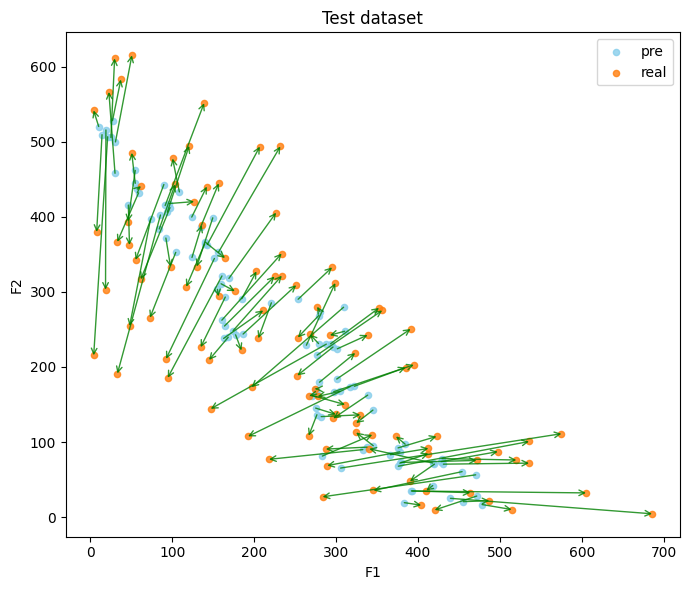

Max:  291.62, sur=[ 21.2708 506.5114], real=[  4.2316 215.3907]
Min:  1.14, sur=[275.8105 170.8898], real=[274.6735 170.905 ]
Mean: 80.55
--------------------------------------------------


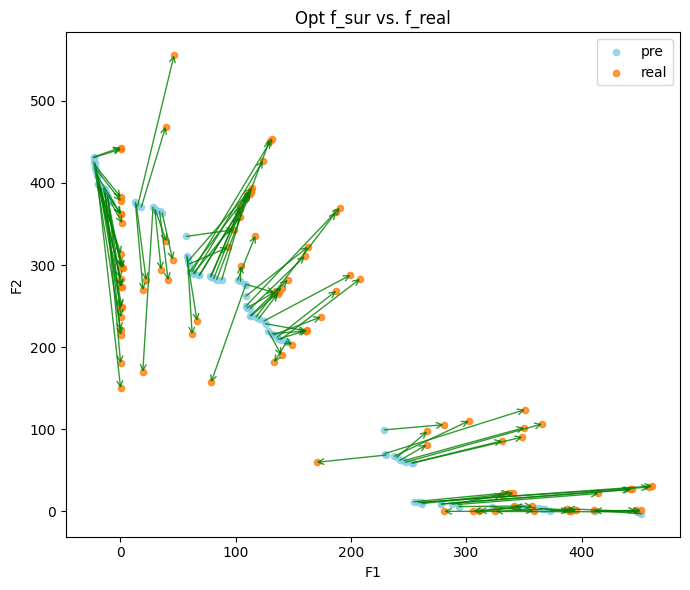

Max:  265.27, sur=[-20.933  414.4709], real=[  0.1276 150.0366]
Min:  6.61, sur=[143.7928 207.0728], real=[148.9546 202.9437]
Mean: 87.55
--------------------------------------------------


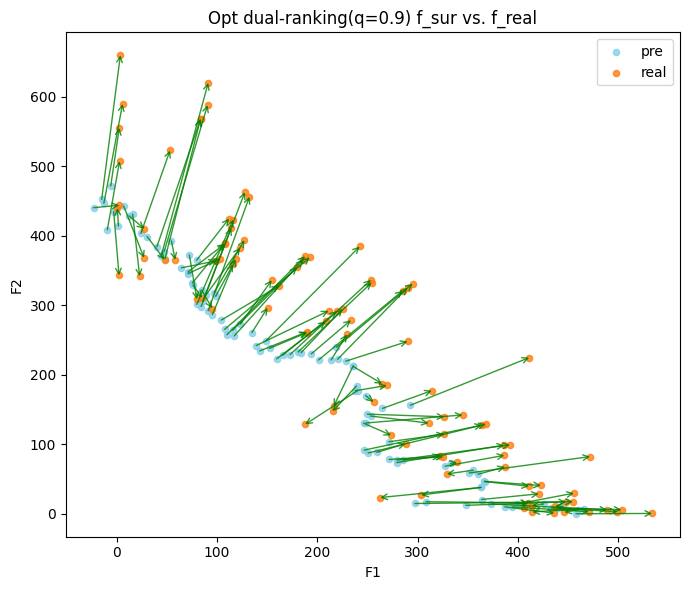

Max:  253.95, sur=[ 44.1396 370.2151], real=[ 91.2097 619.7626]
Min:  2.56, sur=[406.52    11.6871], real=[406.1779   9.146 ]
Mean: 81.39
--------------------------------------------------


In [ ]:
result1 = evaluate_pre_real(y_q50, y_test, title="Test dataset")
result2 = evaluate_pre_real(obj, f_real, title="Opt f_sur vs. f_real")
result3 = evaluate_pre_real(obj_q90, f_real_q90, title="Opt dual-ranking(q=0.9) f_sur vs. f_real")